In [1]:
!pip install optuna

  Using cached colorlog-6.12.0-py3-none-any.whl.metadata (11 kB)
  Using cached mako-1.4.1-py3-none-any.whl.metadata (2.9 kB)
Using cached colorlog-6.12.0-py3-none-any.whl (12 kB)
Using cached mako-1.4.1-py3-none-any.whl (80 kB)

   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   -------------------------

In [3]:
import optuna

print(optuna.__version__)

5.0.0


In [4]:
import pandas as pd
import numpy as np
import optuna

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

In [5]:
iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [6]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
rf = RandomForestClassifier()

score = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=3,
    scoring='accuracy'
)

print(score.mean())

0.9500000000000001


In [8]:
def objective(trial):

    n_estimators = trial.suggest_int(
        "n_estimators",
        50,
        300
    )

    max_depth = trial.suggest_int(
        "max_depth",
        2,
        20
    )

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring='accuracy'
    ).mean()

    return score

In [10]:
study = optuna.create_study(
    direction="maximize"
)

[I 2026-09-19 22:44:24,728] A new study created in memory with name: no-name-cdcf2f8d-8be2-406b-bdfc-46027f2468af


In [11]:
study.optimize(
    objective,
    n_trials=50
)

[I 2026-09-19 22:44:44,785] Trial 0 finished with value: 0.9583333333333334 and parameters: {'n_estimators': 159, 'max_depth': 16}. Best is trial 0 with value: 0.9583333333333334.
[I 2026-09-19 22:44:47,336] Trial 1 finished with value: 0.9500000000000001 and parameters: {'n_estimators': 288, 'max_depth': 9}. Best is trial 0 with value: 0.9583333333333334.
[I 2026-09-19 22:44:48,088] Trial 2 finished with value: 0.9583333333333334 and parameters: {'n_estimators': 75, 'max_depth': 6}. Best is trial 0 with value: 0.9583333333333334.
[I 2026-09-19 22:44:49,594] Trial 3 finished with value: 0.9583333333333334 and parameters: {'n_estimators': 171, 'max_depth': 12}. Best is trial 0 with value: 0.9583333333333334.
[I 2026-09-19 22:44:51,170] Trial 4 finished with value: 0.9583333333333334 and parameters: {'n_estimators': 171, 'max_depth': 10}. Best is trial 0 with value: 0.9583333333333334.
[I 2026-09-19 22:44:53,488] Trial 5 finished with value: 0.9500000000000001 and parameters: {'n_estimat

In [12]:
print(study.best_params)

{'n_estimators': 159, 'max_depth': 16}


In [13]:
print(study.best_value)

0.9583333333333334


In [14]:
best_rf = RandomForestClassifier(
    **study.best_params,
    random_state=42
)

In [15]:
best_rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",159
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [16]:
from sklearn.metrics import accuracy_score

pred = best_rf.predict(X_test)

print(
    accuracy_score(
        y_test,
        pred
    )
)

1.0


C:\Users\Omkar\AppData\Local\Temp\ipykernel_5272\1657672866.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

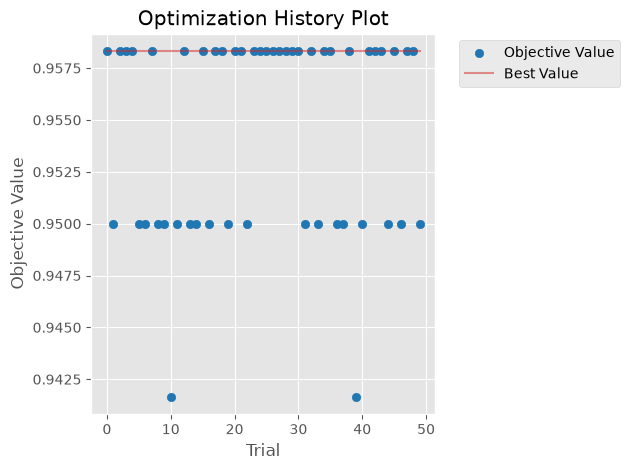

In [17]:
optuna.visualization.matplotlib.plot_optimization_history(
    study
)

C:\Users\Omkar\AppData\Local\Temp\ipykernel_5272\1316664585.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

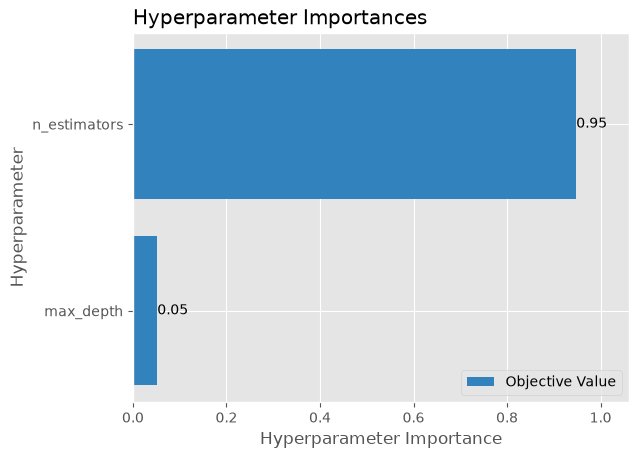

In [18]:
optuna.visualization.matplotlib.plot_param_importances(
    study
)